**<h1 style="color:darkblue; text-align:center;">SALES FUNNEL ANALYSIS</h1>**<h2 style="color:darkblue; text-align:center;">Identifying Conversion Bottlenecks in CRM Opportunities</h2>

**<h2 style="color:purple;">Introduction</h2>** In today’s business environment, organizations rely on CRM systems to manage sales activities and track customer interactions, but the real value lies in analyzing this data to understand how effectively the sales process performs. The sales funnel represents the journey of a potential customer from initial contact to final conversion, where opportunities may either progress or drop off at different stages. This project focuses on analyzing a CRM sales opportunities dataset to evaluate stage-wise conversion rates, identify bottlenecks in the pipeline, and examine factors such as sales teams, products, and sales cycle duration that influence deal outcomes. The objective is to generate actionable insights that can improve sales efficiency, reduce drop-offs, and support better decision-making within the sales process

**<h2 style="color:purple;">Problem statement</h2>** Despite having access to detailed CRM data, organizations often struggle to understand how effectively their sales pipeline converts opportunities into successful deals. It is difficult to identify at which stages prospects drop off, which factors influence deal outcomes, and where inefficiencies exist within the funnel. This lack of clarity can lead to lower conversion rates, longer sales cycles, and missed revenue opportunities. Therefore, there is a need to analyze the sales funnel in a structured manner to identify bottlenecks, evaluate stage-wise performance, and generate insights that can help optimize the overall sales process.

**<h2 style="color:purple;">Aim</h2>** The aim of this project is to analyze the sales funnel within a CRM dataset to evaluate conversion rates across different stages, identify bottlenecks in the pipeline, and examine factors influencing deal outcomes. The project seeks to generate actionable insights that can improve sales efficiency, increase conversion rates, and optimize the overall sales process.

**<h4 style="color:darkgreen;">Objectives**
</h4>

- To analyze the distribution of opportunities across different stages of the sales funnel

- To calculate stage-wise conversion rates and overall win rate

- To identify bottlenecks by detecting stages with high drop-off rates

- To evaluate the performance of sales teams and individual agents

- To analyze the impact of products on deal conversion and revenue generation

- To measure the sales cycle duration and its effect on deal outcomes

- To identify trends and patterns in the sales pipeline over time

- To provide data-driven insights and recommendations to improve sales efficiency and conversion rates

**<h2 style="color:purple;">
Dataset Overview**
</h2>

**<h4 style="color:darkgreen;">Dataset Name**
</h4>

crm_sales_opportunities.csv


**<h4 style="color:darkgreen;">Source**
</h4>

https://mavenanalytics.io/data-playground/crm-sales-opportunities

**<h4 style="color:darkgreen;">Description**
</h4>
This dataset contains detailed information on CRM sales opportunities, designed for analyzing the sales funnel. It includes data points such as `account` details, `product` information, `sales_agent` assignments, `deal_stage` progression, `engage_date` and `close_date`, and `close_value`. The dataset allows for the evaluation of conversion rates, identification of bottlenecks, and analysis of factors influencing deal outcomes within a sales process.

**<h4 style="color:darkgreen;">Column Description</h4>**

- **Account** — Name of the company or customer involved in the sales process.  
- **Sector** — Industry or business domain of the account.  
- **Year_Established** — Year in which the company was founded.  
- **Revenue** — Annual revenue of the company (in millions).  
- **Employees** — Total number of employees in the company.  
- **Office_Location** — Geographic location of the company.  
- **Subsidiary_Of** — Parent company, if the account is a subsidiary.  

- **Product** — Name of the product being sold.  
- **Series** — Category or series to which the product belongs.  
- **Sales_Price** — Price of the product.  

- **Opportunity_ID** — Unique identifier assigned to each sales opportunity.  
- **Sales_Agent** — Sales representative responsible for managing the opportunity.  
- **Deal_Stage** — Current stage of the opportunity in the sales funnel (e.g., Lead, Qualified, Proposal, Won, Lost).  
- **Engage_Date** — Date when the sales engagement with the customer began.  
- **Close_Date** — Date when the deal was closed (won or lost).  
- **Close_Value** — Final value of the deal if successfully closed.  

- **Manager** — Manager overseeing the sales agent.  
- **Regional_Office** — Location of the sales team or regional office.  

<h1 style="color:darkblue;">1. Preprocessing</h1>
This section covers all data preparation steps: importing libraries, loading raw data, initial dataset inspection, integration and feature engineering, and handling missing values to produce a clean, analysis-ready dataframe.

<h2 style="color:purple;">1.1 Import Libraries</h2>

In [177]:
# Data handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import scipy.stats as stats

# Display plots inside the notebook
%matplotlib inline

# Removing warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

<h2 style="color:purple;">1.2 Data Loading</h2>

In [178]:
pipeline = pd.read_csv(r'C:\Users\jomon123\Desktop\Final projrct\CRM+Sales+Opportunities\sales_pipeline.csv')
teams = pd.read_csv(r'C:\Users\jomon123\Desktop\Final projrct\CRM+Sales+Opportunities\sales_teams.csv')
accounts = pd.read_csv(r'C:\Users\jomon123\Desktop\Final projrct\CRM+Sales+Opportunities\accounts.csv')
products = pd.read_csv(r'C:\Users\jomon123\Desktop\Final projrct\CRM+Sales+Opportunities\products.csv')

<h2 style="color:purple;">1.3 Dataset Inspection</h2>
A first look at the raw tables — shape, data types, basic statistics, and null counts — before any transformations are applied.

In [179]:
pipeline.head(10)

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0
5,ZNBS69V1,Anna Snelling,MG Special,Ron-tech,Won,2016-10-29,2017-03-01,49.0
6,9ME3374G,Vicki Laflamme,MG Special,J-Texon,Won,2016-10-30,2017-03-02,57.0
7,7GN8Q4LL,Markita Hansen,GTX Basic,Cheers,Won,2016-11-01,2017-03-07,601.0
8,OLK9LKZB,Niesha Huffines,GTX Plus Basic,Zumgoity,Won,2016-11-01,2017-03-03,1026.0
9,HAXMC4IX,James Ascencio,MG Advanced,NaN,Engaging,2016-11-03,NaN,NaN


<h3 style="color:darkgreen;">Dataset Information</h3>

In [180]:
pipeline.info()
teams.info()
accounts.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   opportunity_id  8800 non-null   object 
 1   sales_agent     8800 non-null   object 
 2   product         8800 non-null   object 
 3   account         7375 non-null   object 
 4   deal_stage      8800 non-null   object 
 5   engage_date     8300 non-null   object 
 6   close_date      6711 non-null   object 
 7   close_value     6711 non-null   float64
dtypes: float64(1), object(7)
memory usage: 550.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sales_agent      35 non-null     object
 1   manager          35 non-null     object
 2   regional_office  35 non-null     object
dtypes: object(3)
memory usage: 972.0+ bytes
<class 'pandas.cor

<h3 style="color:darkgreen;">Dataset Dimensions</h3>

In [181]:
print("Pipeline")
print('No.of rows:', pipeline.shape[0])
print('No.of columns:', pipeline.shape[1])
print("Teams")
print('No.of rows:', teams.shape[0])
print('No.of columns:', teams.shape[1])
print("Accounts")
print('No.of rows:', accounts.shape[0])
print('No.of columns:', accounts.shape[1])
print("Products")
print('No.of rows:', products.shape[0])
print('No.of columns:', products.shape[1])

Pipeline
No.of rows: 8800
No.of columns: 8
Teams
No.of rows: 35
No.of columns: 3
Accounts
No.of rows: 85
No.of columns: 7
Products
No.of rows: 7
No.of columns: 3


<h3 style="color:darkgreen;">Descriptive Statistics</h3>

In [182]:
dataframes = {'Pipeline': pipeline, 'Teams': teams, 'Accounts': accounts, 'Products': products}
for name, df in dataframes.items():
    print(f"{name} Summary")
    print(df.describe())
    print("\n")

Pipeline Summary
        close_value
count   6711.000000
mean    1490.915512
std     2320.670773
min        0.000000
25%        0.000000
50%      472.000000
75%     3225.000000
max    30288.000000


Teams Summary
          sales_agent        manager regional_office
count              35             35              35
unique             35              6               3
top     Anna Snelling  Melvin Marxen            East
freq                1              6              12


Accounts Summary
       year_established       revenue     employees
count         85.000000     85.000000     85.000000
mean        1996.105882   1994.632941   4660.823529
std            8.865427   2169.491436   5715.601198
min         1979.000000      4.540000      9.000000
25%         1989.000000    497.110000   1179.000000
50%         1996.000000   1223.720000   2769.000000
75%         2002.000000   2741.370000   5595.000000
max         2017.000000  11698.030000  34288.000000


Products Summary
        sales_pr

<h3 style="color:darkgreen;">Missing Values (Raw Tables)</h3>

In [183]:
# List your tables to compare totals
for name, df in {'Pipeline': pipeline, 'Products': products, 'Accounts': accounts, 'Teams': teams}.items():
    print(f"{name} total nulls: {df.isnull().sum()}")

Pipeline total nulls: opportunity_id       0
sales_agent          0
product              0
account           1425
deal_stage           0
engage_date        500
close_date        2089
close_value       2089
dtype: int64
Products total nulls: product        0
series         0
sales_price    0
dtype: int64
Accounts total nulls: account              0
sector               0
year_established     0
revenue              0
employees            0
office_location      0
subsidiary_of       70
dtype: int64
Teams total nulls: sales_agent        0
manager            0
regional_office    0
dtype: int64


<h2 style="color:purple;">1.4 Data Integration & Feature Engineering</h2>
Merging the four raw tables into a single analytical dataframe and engineering key derived features such as `sales_cycle_days`, `deal_won`, `deal_size`, and `deal_status`.

In [184]:
# Merge datasets
analysis_df = pipeline.copy()

# Merging with accounts and products
analysis_df = analysis_df.merge(accounts, on='account', how='left')
analysis_df = analysis_df.merge(products, on='product', how='left')

# Feature engineering
analysis_df['engage_date'] = pd.to_datetime(analysis_df['engage_date'], errors='coerce')
analysis_df['close_date'] = pd.to_datetime(analysis_df['close_date'], errors='coerce')

# Create sales_cycle_days BEFORE it is used in Phase 2/3
analysis_df['sales_cycle_days'] = (analysis_df['close_date'] - analysis_df['engage_date']).dt.days

analysis_df['deal_won'] = (analysis_df['deal_stage'] == 'Won').astype(int)

# Handling potential NaNs in close_value and numeric fields
analysis_df['close_value_filled'] = analysis_df['close_value'].fillna(0)
analysis_df['revenue'] = analysis_df['revenue'].fillna(analysis_df['revenue'].median())
analysis_df['employees'] = analysis_df['employees'].fillna(analysis_df['employees'].median())

analysis_df['deal_size'] = pd.cut(
    analysis_df['close_value_filled'],
    bins=[-1, 500, 2000, 5000, 100000],
    labels=['Small', 'Medium', 'Large', 'Enterprise']
)

print(f"Enriched dataset: {analysis_df.shape[0]} rows x {analysis_df.shape[1]} columns")
display(analysis_df.head())

Enriched dataset: 8800 rows x 20 columns


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,sales_cycle_days,deal_won,close_value_filled,deal_size
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,retail,2001.0,718.62,2448.0,United States,NaN,GTX,1096.0,132.0,1,1054.0,Medium
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,medical,2002.0,3178.24,4540.0,United States,NaN,NaN,NaN,137.0,1,4514.0,Large
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,retail,2001.0,718.62,2448.0,United States,NaN,MG,55.0,133.0,1,50.0,Small
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,software,1998.0,2714.90,2641.0,United States,Acme Corporation,GTX,550.0,135.0,1,588.0,Medium
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,services,1982.0,792.46,1299.0,United States,NaN,GTX,550.0,128.0,1,517.0,Medium


<h2 style="color:purple;">1.5 Enriched Dataset Inspection</h2>
Verifying the merged dataframe — checking info, shape, value counts, duplicates, and null distribution.

In [185]:
print("--- Info ---")
analysis_df.info()


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   opportunity_id      8800 non-null   object        
 1   sales_agent         8800 non-null   object        
 2   product             8800 non-null   object        
 3   account             7375 non-null   object        
 4   deal_stage          8800 non-null   object        
 5   engage_date         8300 non-null   datetime64[ns]
 6   close_date          6711 non-null   datetime64[ns]
 7   close_value         6711 non-null   float64       
 8   sector              7375 non-null   object        
 9   year_established    7375 non-null   float64       
 10  revenue             8800 non-null   float64       
 11  employees           8800 non-null   float64       
 12  office_location     7375 non-null   object        
 13  subsidiary_of       1292 non-null  

In [186]:
print("\n--- Descriptive Statistics ---")
display(analysis_df.describe())



--- Descriptive Statistics ---


,engage_date,close_date,close_value,year_established,revenue,employees,sales_price,sales_cycle_days,deal_won,close_value_filled
count,8300,6711,6711.000000,7375.000000,8800.000000,8800.000000,7320.000000,6711.000000,8800.000000,8800.000000
mean,2017-06-14 08:35:06.216867584,2017-08-01 03:32:25.641484032,1490.915512,1995.483661,2342.938873,5343.471477,1885.394126,47.985397,0.481591,1136.992500
min,2016-10-20 00:00:00,2017-03-01 00:00:00,0.000000,1979.000000,4.540000,9.000000,55.000000,1.000000,0.000000,0.000000
25%,2017-04-04 00:00:00,2017-05-18 00:00:00,0.000000,1988.000000,718.620000,1588.000000,550.000000,8.000000,0.000000,0.000000
50%,2017-06-24 00:00:00,2017-08-02 00:00:00,472.000000,1995.000000,1698.200000,3492.000000,1096.000000,45.000000,0.000000,0.000000
75%,2017-08-27 00:00:00,2017-10-18 00:00:00,3225.000000,2002.000000,2819.500000,6472.000000,3393.000000,85.000000,1.000000,1085.250000
max,2017-12-27 00:00:00,2017-12-31 00:00:00,30288.000000,2017.000000,11698.030000,34288.000000,26768.000000,138.000000,1.000000,30288.000000
std,NaN,NaN,2320.670773,9.187126,2393.473911,6293.189490,2619.399523,41.057665,0.499689,2123.528615


In [187]:
print("\n--- Columns ---")
print(analysis_df.columns)


--- Columns ---
Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value', 'sector',
       'year_established', 'revenue', 'employees', 'office_location',
       'subsidiary_of', 'series', 'sales_price', 'sales_cycle_days',
       'deal_won', 'close_value_filled', 'deal_size'],
      dtype='object')


In [188]:
print("\n--- Shape ---")
print(analysis_df.shape)


--- Shape ---
(8800, 20)


In [189]:
print("\n--- Data Head ---")
display(analysis_df.head())


--- Data Head ---


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,sales_cycle_days,deal_won,close_value_filled,deal_size
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0,retail,2001.0,718.62,2448.0,United States,NaN,GTX,1096.0,132.0,1,1054.0,Medium
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0,medical,2002.0,3178.24,4540.0,United States,NaN,NaN,NaN,137.0,1,4514.0,Large
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0,retail,2001.0,718.62,2448.0,United States,NaN,MG,55.0,133.0,1,50.0,Small
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0,software,1998.0,2714.90,2641.0,United States,Acme Corporation,GTX,550.0,135.0,1,588.0,Medium
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0,services,1982.0,792.46,1299.0,United States,NaN,GTX,550.0,128.0,1,517.0,Medium


In [190]:
print("\n--- Data Sample ---")
display(analysis_df.sample(5))


--- Data Sample ---


,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value,sector,year_established,revenue,employees,office_location,subsidiary_of,series,sales_price,sales_cycle_days,deal_won,close_value_filled,deal_size
1098,0WWDVOM3,Rosalina Dieter,MG Special,Condax,Won,2017-02-25,2017-05-09,50.0,medical,2017.0,4.54,9.0,United States,NaN,MG,55.0,73.0,1,50.0,Small
6346,NUS67BOQ,Rosie Papadopoulos,GTX Basic,NaN,Engaging,2017-08-31,NaT,NaN,NaN,NaN,1698.20,3492.0,NaN,NaN,GTX,550.0,NaN,0,0.0,Small
8245,PM2BF2KB,Cassey Cress,GTX Plus Basic,Xx-holding,Engaging,2017-12-13,NaT,NaN,finance,1993.0,7537.24,20293.0,United States,NaN,GTX,1096.0,NaN,0,0.0,Small
2303,30YWHJV8,Donn Cantrell,GTX Plus Basic,Plussunin,Lost,2017-04-11,2017-04-18,0.0,retail,2003.0,1419.98,4018.0,United States,NaN,GTX,1096.0,7.0,0,0.0,Small
7047,EK06CNRW,Lajuana Vencill,MG Advanced,Bioholding,Won,2017-09-27,2017-10-06,3681.0,medical,2012.0,587.34,1356.0,Philipines,NaN,MG,3393.0,9.0,1,3681.0,Large


In [191]:
print('\n--- Unique Value Count ---')
print(analysis_df.nunique())



--- Unique Value Count ---
opportunity_id        8800
sales_agent             30
product                  7
account                 85
deal_stage               4
engage_date            421
close_date             306
close_value           2051
sector                  10
year_established        35
revenue                 85
employees               85
office_location         15
subsidiary_of            7
series                   3
sales_price              6
sales_cycle_days       138
deal_won                 2
close_value_filled    2051
deal_size                4
dtype: int64


In [192]:
print('\n--- Data Types ---')
print(analysis_df.dtypes)


--- Data Types ---
opportunity_id                object
sales_agent                   object
product                       object
account                       object
deal_stage                    object
engage_date           datetime64[ns]
close_date            datetime64[ns]
close_value                  float64
sector                        object
year_established             float64
revenue                      float64
employees                    float64
office_location               object
subsidiary_of                 object
series                        object
sales_price                  float64
sales_cycle_days             float64
deal_won                       int64
close_value_filled           float64
deal_size                   category
dtype: object


In [193]:
print('\n--- Duplicated Rows ---')
print(analysis_df.duplicated().sum())


--- Duplicated Rows ---
0


In [194]:
print("\n--- Value Counts (Deal Stage) ---")
print(analysis_df['deal_stage'].value_counts())


--- Value Counts (Deal Stage) ---
deal_stage
Won            4238
Lost           2473
Engaging       1589
Prospecting     500
Name: count, dtype: int64


In [195]:
print("\n--- Value Counts (Product) ---")
print(analysis_df['product'].value_counts())


--- Value Counts (Product) ---
product
GTX Basic         1866
MG Special        1651
GTXPro            1480
MG Advanced       1412
GTX Plus Basic    1383
GTX Plus Pro       968
GTK 500             40
Name: count, dtype: int64


In [196]:
# Check for null values in entire DataFrame
print("Null values count per column:")
print(analysis_df.isnull().sum())
print("\nPercentage of null values per column:")
print((analysis_df.isnull().sum() / len(analysis_df) * 100).round(2))

# Check if any row has null values
print("\nRows with null values:")
print(analysis_df[analysis_df.isnull().any(axis=1)])

Null values count per column:
opportunity_id           0
sales_agent              0
product                  0
account               1425
deal_stage               0
engage_date            500
close_date            2089
close_value           2089
sector                1425
year_established      1425
revenue                  0
employees                0
office_location       1425
subsidiary_of         7508
series                1480
sales_price           1480
sales_cycle_days      2089
deal_won                 0
close_value_filled       0
deal_size                0
dtype: int64

Percentage of null values per column:
opportunity_id         0.00
sales_agent            0.00
product                0.00
account               16.19
deal_stage             0.00
engage_date            5.68
close_date            23.74
close_value           23.74
sector                16.19
year_established      16.19
revenue                0.00
employees              0.00
office_location       16.19
subsidiary_of 

<h2 style="color:purple;">1.6 Data Cleaning</h2>
Dropping irrelevant columns, filling missing values in close values and dates, imputing categorical and numerical fields, recalculating derived features, and finalising deal status.

In [197]:
analysis_df = analysis_df.drop('subsidiary_of', axis=1)
print("Dropped 'subsidiary_of' column.")
print(analysis_df.columns)

Dropped 'subsidiary_of' column.
Index(['opportunity_id', 'sales_agent', 'product', 'account', 'deal_stage',
       'engage_date', 'close_date', 'close_value', 'sector',
       'year_established', 'revenue', 'employees', 'office_location', 'series',
       'sales_price', 'sales_cycle_days', 'deal_won', 'close_value_filled',
       'deal_size'],
      dtype='object')


In [198]:

# Handle missing Close Value and Dates
# If a deal is not 'Won', the close_value should be 0 rather than NaN
analysis_df['close_value'] = analysis_df['close_value'].fillna(0)

# Fill missing engagement dates with the most common date or drop if critical
# For this analysis, we will drop rows where engage_date is missing as we can't calculate cycles
analysis_df = analysis_df.dropna(subset=['engage_date'])

print("Close values filled and missing engagement dates dropped.")

Close values filled and missing engagement dates dropped.


In [199]:
# Impute Categorical and Account Information
# Fill missing categorical strings with 'Unknown'
cat_cols = ['account', 'sector', 'office_location', 'series']
for col in cat_cols:
    analysis_df[col] = analysis_df[col].fillna('Unknown')

# Fill missing account metrics with median to avoid outlier influence
num_cols = ['revenue', 'employees', 'year_established', 'sales_price']
for col in num_cols:
    analysis_df[col] = analysis_df[col].fillna(analysis_df[col].median())

print("Categorical and numerical account data imputed.")

Categorical and numerical account data imputed.


In [200]:
# Recalculate Derived Features
# Recalculate sales cycle (filling missing close_date with engage_date for 0-day cycles if necessary)
analysis_df['close_date_filled'] = analysis_df['close_date'].fillna(analysis_df['engage_date'])
analysis_df['sales_cycle_days'] = (analysis_df['close_date_filled'] - analysis_df['engage_date']).dt.days

# Re-bin the deal_size now that close_value is filled
analysis_df['deal_size'] = pd.cut(
    analysis_df['close_value'],
    bins=[-1, 500, 2000, 5000, 100000],
    labels=['Small', 'Medium', 'Large', 'Enterprise']
)

print("Derived features updated. Final Null Check:")
display(analysis_df.isnull().sum())

Derived features updated. Final Null Check:


opportunity_id           0
sales_agent              0
product                  0
account                  0
deal_stage               0
engage_date              0
close_date            1589
close_value              0
sector                   0
year_established         0
revenue                  0
employees                0
office_location          0
series                   0
sales_price              0
sales_cycle_days         0
deal_won                 0
close_value_filled       0
deal_size                0
close_date_filled        0
dtype: int64

In [201]:
# Handle remaining nulls in close_date by identifying the deal status
# Nulls in close_date typically mean the opportunity is still 'Engaging' or 'Prospecting'

# Create a status column to distinguish between completed and active deals
analysis_df['deal_status'] = np.where(analysis_df['close_date'].isnull(), 'Active', 'Settled')

print("Deal Status Distribution:")
print(analysis_df['deal_status'].value_counts())

inconsistent_deals = analysis_df[(analysis_df['deal_stage'].isin(['Won', 'Lost'])) & (analysis_df['close_date'].isnull())]
print(f"\nInconsistent deals (Won/Lost but no close_date): {len(inconsistent_deals)}")


Deal Status Distribution:
deal_status
Settled    6711
Active     1589
Name: count, dtype: int64

Inconsistent deals (Won/Lost but no close_date): 0


In [202]:
display(analysis_df.isnull().sum())
print(analysis_df)

opportunity_id           0
sales_agent              0
product                  0
account                  0
deal_stage               0
engage_date              0
close_date            1589
close_value              0
sector                   0
year_established         0
revenue                  0
employees                0
office_location          0
series                   0
sales_price              0
sales_cycle_days         0
deal_won                 0
close_value_filled       0
deal_size                0
close_date_filled        0
deal_status              0
dtype: int64

     opportunity_id       sales_agent         product        account  \
0          1C1I7A6R       Moses Frase  GTX Plus Basic        Cancity   
1          Z063OYW0   Darcel Schlecht          GTXPro          Isdom   
2          EC4QE1BX   Darcel Schlecht      MG Special        Cancity   
3          MV1LWRNH       Moses Frase       GTX Basic        Codehow   
4          PE84CX4O         Zane Levy       GTX Basic         Hatfan   
...             ...               ...             ...            ...   
8295       2EBLR9N8   Lajuana Vencill       GTX Basic        Conecom   
8296       VDGA4KXA  Violet Mclelland  GTX Plus Basic  Bluth Company   
8297       6WCNNK5J   Maureen Marcano          GTXPro       Hottechi   
8298       YJTQSZ9D  Gladys Colclough  GTX Plus Basic          Inity   
8299       RB8GDYFY  Gladys Colclough      MG Special       Betatech   

     deal_stage engage_date close_date  close_value     sector  \
0           Won  2016-10-20 2017-03-01       1054.0     retail   
1  

<h1 style='color:darkblue;'>2. Outlier Handling</h1>
Outliers are detected using the <b>percentile method</b>: values below the 5th percentile and above the 95th percentile are flagged for each key numerical column. Detected outlier rows are then <b>removed</b> from the dataset to produce a clean dataframe for analysis.

In [203]:
# Numerical columns to inspect for outliers
num_cols_to_fix = ['close_value', 'revenue', 'employees', 'sales_cycle_days']
print(f"Rows before outlier removal: {analysis_df.shape[0]}")

Rows before outlier removal: 8300


<h3 style='color:purple'>Detect Outliers — close_value</h3>

In [204]:
max_threshold_cv = analysis_df['close_value'].quantile(0.95)
min_threshold_cv = analysis_df['close_value'].quantile(0.05)
print(f'close_value  |  min threshold (5th pct): {min_threshold_cv}  |  max threshold (95th pct): {max_threshold_cv}')

close_value  |  min threshold (5th pct): 0.0  |  max threshold (95th pct): 5304.049999999999


In [205]:
# Records ABOVE the 95th percentile
print(f"Records above max threshold: {len(analysis_df[analysis_df['close_value'] > max_threshold_cv])}")
analysis_df[analysis_df['close_value'] > max_threshold_cv][['opportunity_id','sales_agent','deal_stage','close_value']].head(10)

Records above max threshold: 415


,opportunity_id,sales_agent,deal_stage,close_value
58,WPB2SLIG,Donn Cantrell,Won,5585.0
59,XUSUEAV7,Elease Gluck,Won,25897.0
68,GIUUTBXM,Kary Hendrixson,Won,5539.0
80,LXZA2OSZ,Corliss Cosme,Won,5790.0
97,J7YF6DS7,Corliss Cosme,Won,5964.0
110,2XQAKBXH,Zane Levy,Won,5370.0
111,7G7YLGJO,Zane Levy,Won,6499.0
134,22OFSXBT,Jonathan Berthelot,Won,5406.0
149,45A57X68,Darcel Schlecht,Won,5522.0
151,JLWKWQYC,James Ascencio,Won,5673.0


In [206]:
# Records BELOW the 5th percentile
print(f"Records below min threshold: {len(analysis_df[analysis_df['close_value'] < min_threshold_cv])}")
analysis_df[analysis_df['close_value'] < min_threshold_cv][['opportunity_id','sales_agent','deal_stage','close_value']].head(10)

Records below min threshold: 0


,opportunity_id,sales_agent,deal_stage,close_value


<h3 style='color:purple'>Detect Outliers — revenue</h3>

In [207]:
max_threshold_rev = analysis_df['revenue'].quantile(0.95)
min_threshold_rev = analysis_df['revenue'].quantile(0.05)
print(f'revenue  |  min threshold (5th pct): {min_threshold_rev}  |  max threshold (95th pct): {max_threshold_rev}')

revenue  |  min threshold (5th pct): 71.12  |  max threshold (95th pct): 7708.38


In [208]:
print(f"Records above max threshold: {len(analysis_df[analysis_df['revenue'] > max_threshold_rev])}")
analysis_df[analysis_df['revenue'] > max_threshold_rev][['account','sector','revenue']].head(10)

Records above max threshold: 393


,account,sector,revenue
66,Kan-code,software,11698.03
191,Hottechi,technolgy,8170.38
213,Kan-code,software,11698.03
217,Hottechi,technolgy,8170.38
258,Hottechi,technolgy,8170.38
259,Kan-code,software,11698.03
331,Kan-code,software,11698.03
368,Hottechi,technolgy,8170.38
394,Hottechi,technolgy,8170.38
422,Hottechi,technolgy,8170.38


In [209]:
print(f"Records below min threshold: {len(analysis_df[analysis_df['revenue'] < min_threshold_rev])}")
analysis_df[analysis_df['revenue'] < min_threshold_rev][['account','sector','revenue']].head(10)

Records below min threshold: 367


,account,sector,revenue
46,Golddex,finance,52.50
106,Condax,medical,4.54
116,Scottech,marketing,45.39
131,Golddex,finance,52.50
148,Condax,medical,4.54
204,Condax,medical,4.54
246,Zencorporation,technolgy,40.79
308,Condax,medical,4.54
314,Condax,medical,4.54
376,Zencorporation,technolgy,40.79


<h3 style='color:purple'>Detect Outliers — employees</h3>

In [210]:
max_threshold_emp = analysis_df['employees'].quantile(0.95)
min_threshold_emp = analysis_df['employees'].quantile(0.05)
print(f'employees  |  min threshold (5th pct): {min_threshold_emp}  |  max threshold (95th pct): {max_threshold_emp}')

employees  |  min threshold (5th pct): 144.0  |  max threshold (95th pct): 17479.0


In [211]:
print(f"Records above max threshold: {len(analysis_df[analysis_df['employees'] > max_threshold_emp])}")
analysis_df[analysis_df['employees'] > max_threshold_emp][['account','sector','employees']].head(10)

Records above max threshold: 350


,account,sector,employees
32,Xx-holding,finance,20293.0
66,Kan-code,software,34288.0
123,Initech,telecommunications,20275.0
146,Xx-holding,finance,20293.0
147,Initech,telecommunications,20275.0
152,Xx-holding,finance,20293.0
213,Kan-code,software,34288.0
245,Initech,telecommunications,20275.0
259,Kan-code,software,34288.0
264,Initech,telecommunications,20275.0


In [212]:
print(f"Records below min threshold: {len(analysis_df[analysis_df['employees'] < min_threshold_emp])}")
analysis_df[analysis_df['employees'] < min_threshold_emp][['account','sector','employees']].head(10)

Records below min threshold: 374


,account,sector,employees
78,Dalttechnology,software,96.0
106,Condax,medical,9.0
116,Scottech,marketing,100.0
148,Condax,medical,9.0
187,Dalttechnology,software,96.0
204,Condax,medical,9.0
246,Zencorporation,technolgy,142.0
278,Dalttechnology,software,96.0
308,Condax,medical,9.0
314,Condax,medical,9.0


<h3 style='color:purple'>Detect Outliers — sales_cycle_days</h3>

In [213]:
max_threshold_scd = analysis_df['sales_cycle_days'].quantile(0.95)
min_threshold_scd = analysis_df['sales_cycle_days'].quantile(0.05)
print(f'sales_cycle_days  |  min threshold (5th pct): {min_threshold_scd}  |  max threshold (95th pct): {max_threshold_scd}')

sales_cycle_days  |  min threshold (5th pct): 0.0  |  max threshold (95th pct): 112.0


In [214]:
print(f"Records above max threshold: {len(analysis_df[analysis_df['sales_cycle_days'] > max_threshold_scd])}")
analysis_df[analysis_df['sales_cycle_days'] > max_threshold_scd][['opportunity_id','sales_agent','deal_stage','sales_cycle_days']].head(10)

Records above max threshold: 403


,opportunity_id,sales_agent,deal_stage,sales_cycle_days
0,1C1I7A6R,Moses Frase,Won,132
1,Z063OYW0,Darcel Schlecht,Won,137
2,EC4QE1BX,Darcel Schlecht,Won,133
3,MV1LWRNH,Moses Frase,Won,135
4,PE84CX4O,Zane Levy,Won,128
5,ZNBS69V1,Anna Snelling,Won,123
6,9ME3374G,Vicki Laflamme,Won,123
7,7GN8Q4LL,Markita Hansen,Won,126
8,OLK9LKZB,Niesha Huffines,Won,122
10,NL3JZH1Z,Anna Snelling,Won,126


In [215]:
print(f"Records below min threshold: {len(analysis_df[analysis_df['sales_cycle_days'] < min_threshold_scd])}")
analysis_df[analysis_df['sales_cycle_days'] < min_threshold_scd][['opportunity_id','sales_agent','deal_stage','sales_cycle_days']].head(10)

Records below min threshold: 0


,opportunity_id,sales_agent,deal_stage,sales_cycle_days


<h3 style='color:purple'>Remove Outliers</h3>
Filter the dataframe to retain only rows within the 5th–95th percentile range across all four columns.

In [216]:
analysis_df = analysis_df[
    (analysis_df['close_value']       >= min_threshold_cv)  & (analysis_df['close_value']       <= max_threshold_cv)  &
    (analysis_df['revenue']           >= min_threshold_rev) & (analysis_df['revenue']           <= max_threshold_rev) &
    (analysis_df['employees']         >= min_threshold_emp) & (analysis_df['employees']         <= max_threshold_emp) &
    (analysis_df['sales_cycle_days']  >= min_threshold_scd) & (analysis_df['sales_cycle_days']  <= max_threshold_scd)
]

print(f"Rows after outlier removal : {analysis_df.shape[0]}")
analysis_df[num_cols_to_fix].describe()

Rows after outlier removal : 6633


,close_value,revenue,employees,sales_cycle_days
count,6633.000000,6633.000000,6633.000000,6633.000000
mean,898.935625,2007.892296,4370.467511,33.385346
std,1587.528630,1602.107158,3696.782246,37.933094
min,0.000000,71.120000,144.000000,0.000000
25%,0.000000,882.120000,1635.000000,1.000000
50%,0.000000,1698.200000,3492.000000,10.000000
75%,954.000000,2714.900000,5374.000000,71.000000
max,5304.000000,7708.380000,17479.000000,112.000000


<h1 style="color:darkblue;">3. Exploratory Data Analysis (EDA)</h1>
Statistical exploration of the cleaned dataset — examining distributions, relationships between variables, and patterns across multiple dimensions.

<h2 style="color:purple;">3.1 Statistical Overview</h2>
Skewness of key numerical features and aggregated sector-level performance metrics.

In [217]:
print("--- Skewness of Numerical Features ---")
# Ensure we reference columns that exist after cleaning
print(analysis_df[num_cols_to_fix].skew())

print("\n--- Sector Performance Summary ---")
# Fixed: Using 'sector' instead of non-existent 'regional_office'
sector_stats = analysis_df.groupby('sector').agg({
    'opportunity_id': 'count',
    'close_value': ['sum', 'mean'],
    'deal_won': 'mean'
})
display(sector_stats)

--- Skewness of Numerical Features ---
close_value         1.670203
revenue             1.537606
employees           1.578316
sales_cycle_days    0.704466
dtype: float64

--- Sector Performance Summary ---


opportunity_id close_value               deal_won
                            count         sum         mean      mean
sector                                                              
Unknown                      1088         0.0     0.000000  0.000000
employment                    277    277555.0  1002.003610  0.555957
entertainment                 381    419230.0  1100.341207  0.556430
finance                       452    485615.0  1074.369469  0.530973
marketing                     524    590752.0  1127.389313  0.583969
medical                       771    774454.0  1004.479896  0.531777
retail                       1214   1333381.0  1098.336903  0.560956
services                      338    382216.0  1130.816568  0.547337
software                      430    489977.0  1139.481395  0.572093
technolgy                     785    853612.0  1087.403822  0.560510
telecommunications            373    355848.0   954.016086  0.549598

<h2 style="color:purple;">3.2 Univariate Analysis</h2>
Examining the distribution of individual variables — deal stage composition and the spread of close values.

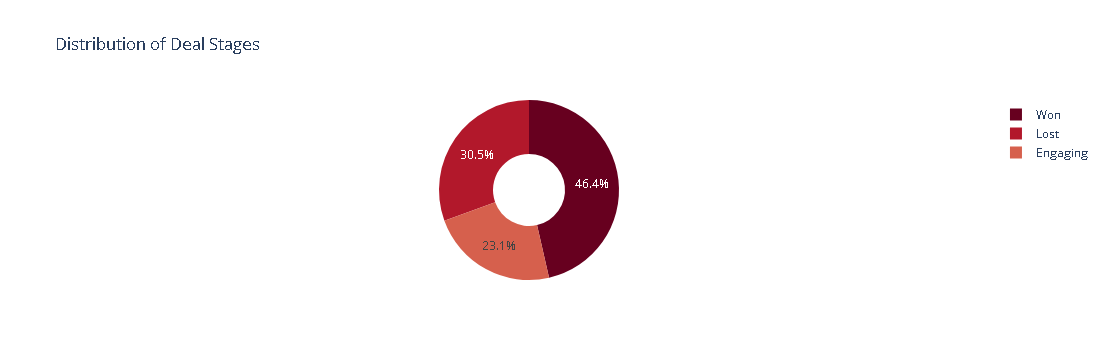

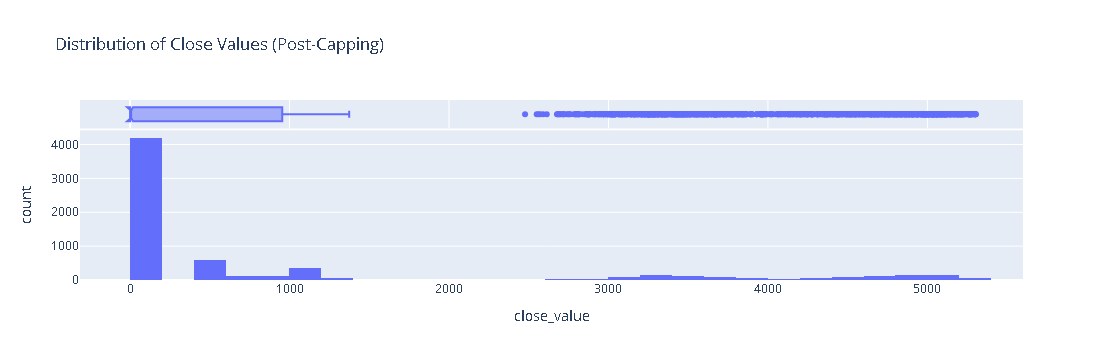

In [218]:
fig_stage = px.pie(analysis_df, names='deal_stage', title='Distribution of Deal Stages',
             hole=0.4, color_discrete_sequence=px.colors.sequential.RdBu)
fig_stage.show()

fig_hist = px.histogram(analysis_df, x='close_value', nbins=30,
                   title='Distribution of Close Values (Post-Capping)',
                   marginal='box')
fig_hist.show()

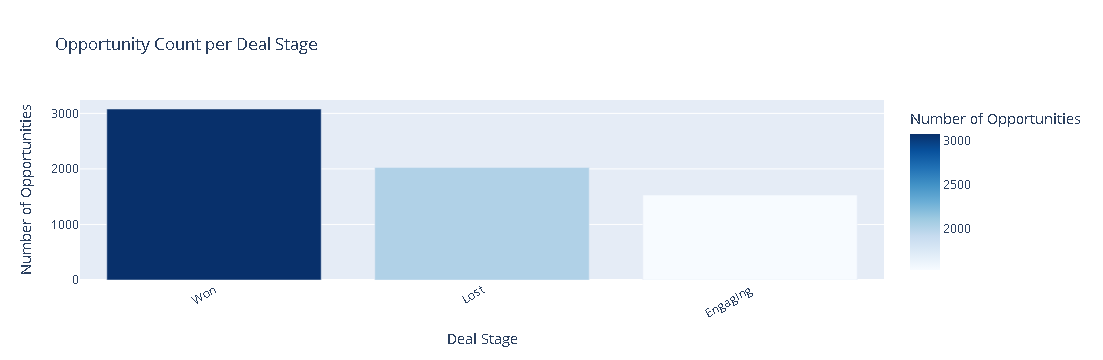

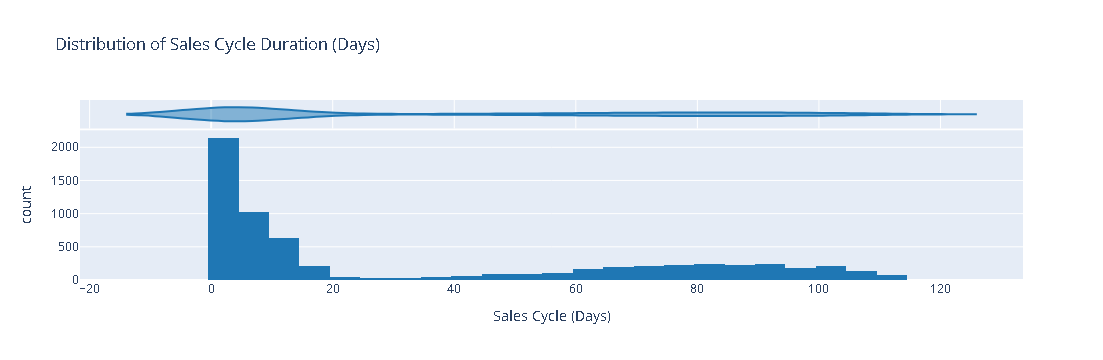

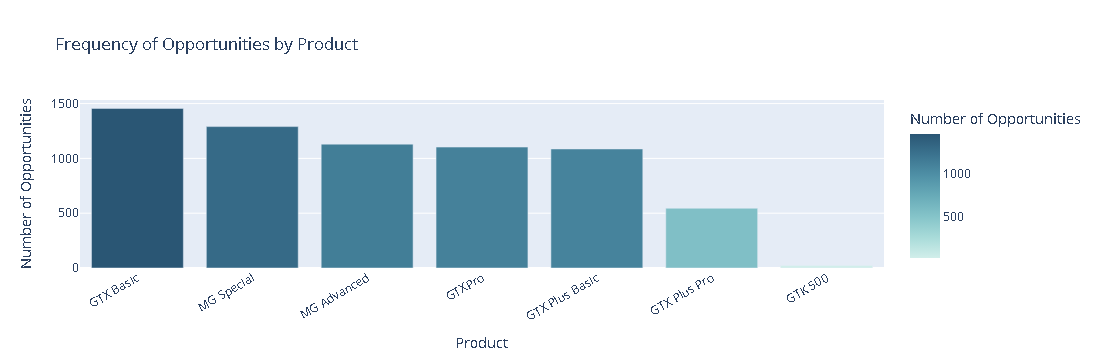

In [219]:
# Univariate Visual 3: Deal Stage Count Bar Chart
stage_counts_u = analysis_df['deal_stage'].value_counts().reset_index()
stage_counts_u.columns = ['deal_stage', 'count']

fig_stage_bar = px.bar(
    stage_counts_u, x='deal_stage', y='count',
    title='Opportunity Count per Deal Stage',
    color='count', color_continuous_scale='Blues',
    labels={'count': 'Number of Opportunities', 'deal_stage': 'Deal Stage'}
)
fig_stage_bar.update_layout(xaxis_tickangle=-30)
fig_stage_bar.show()

# Univariate Visual 4: Sales Cycle Days Distribution
fig_cycle_dist = px.histogram(
    analysis_df.dropna(subset=['sales_cycle_days']),
    x='sales_cycle_days', nbins=40, marginal='violin',
    title='Distribution of Sales Cycle Duration (Days)',
    color_discrete_sequence=['#1f77b4'],
    labels={'sales_cycle_days': 'Sales Cycle (Days)'}
)
fig_cycle_dist.show()

# Univariate Visual 5: Product frequency bar chart
product_counts = analysis_df['product'].value_counts().reset_index()
product_counts.columns = ['product', 'count']
fig_product_bar = px.bar(
    product_counts, x='product', y='count',
    title='Frequency of Opportunities by Product',
    color='count', color_continuous_scale='Teal',
    labels={'count': 'Number of Opportunities', 'product': 'Product'}
)
fig_product_bar.update_layout(xaxis_tickangle=-30)
fig_product_bar.show()


### **Key Insights**

The opportunity count bar chart confirms that the pipeline is well-distributed across most deal stages, yet the **Won** and **Lost** categories dominate, revealing a pipeline where opportunities reach a resolution rather than stall. The sales cycle duration histogram is notably right-skewed, with most deals closing within 0–100 days, while a long tail of slower deals indicates complex negotiations. The product frequency chart highlights that **GTX Basic** and **GTX Pro** attract the highest lead volumes, providing the foundation for the funnel's mid-tier performance and reinforcing the importance of these SKUs in the overall revenue mix.


<h2 style="color:purple;">3.3 Bivariate Analysis</h2>
Analysing pairwise relationships — sales cycle duration across deal stages and total revenue generated per product.

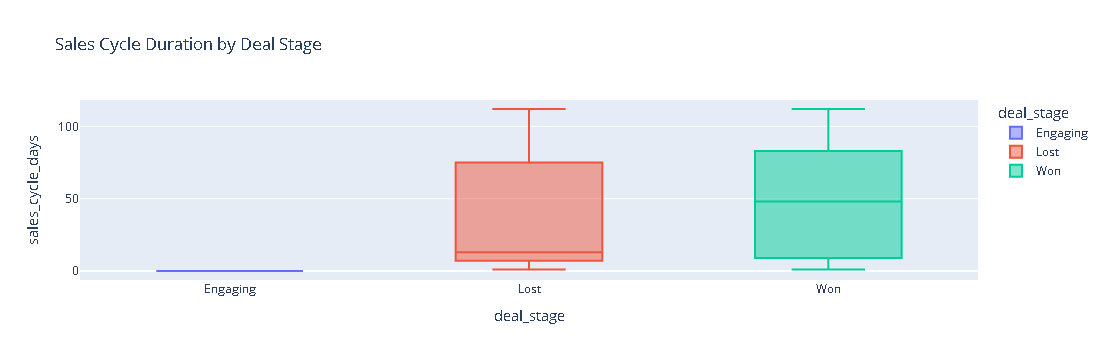

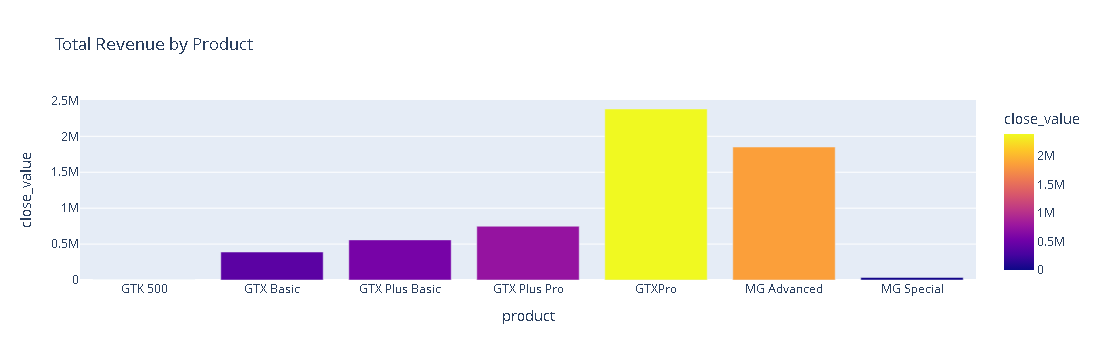

In [220]:
# Filter out NaNs for the box plot to avoid errors
plot_df = analysis_df.dropna(subset=['sales_cycle_days'])

fig_box = px.box(plot_df, x='deal_stage', y='sales_cycle_days',
             color='deal_stage', title='Sales Cycle Duration by Deal Stage')
fig_box.show()

fig_bar_data = analysis_df.groupby('product')['close_value'].sum().reset_index()
fig_bar = px.bar(fig_bar_data, x='product', y='close_value', title='Total Revenue by Product',
             color='close_value')
fig_bar.show()

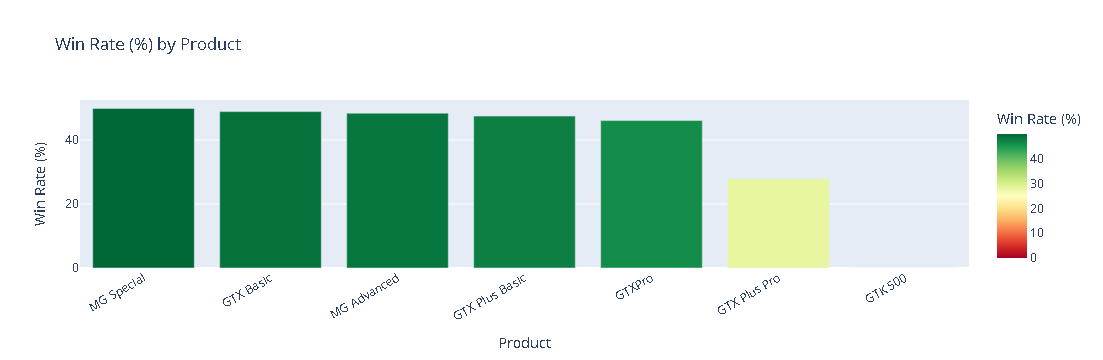

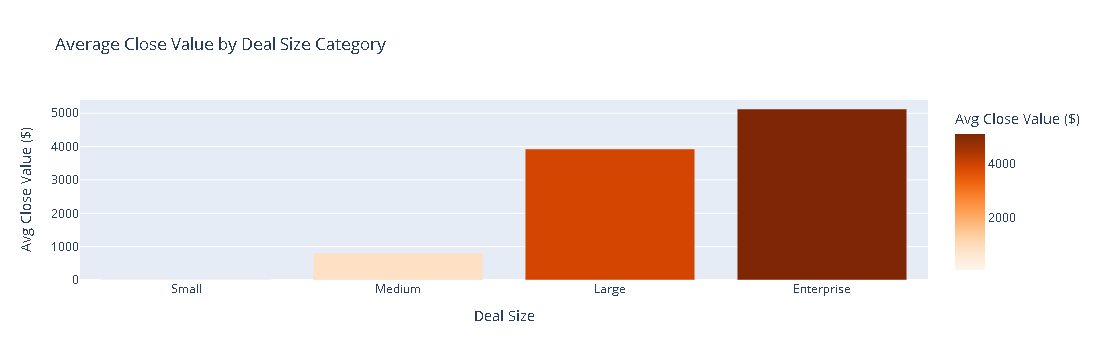

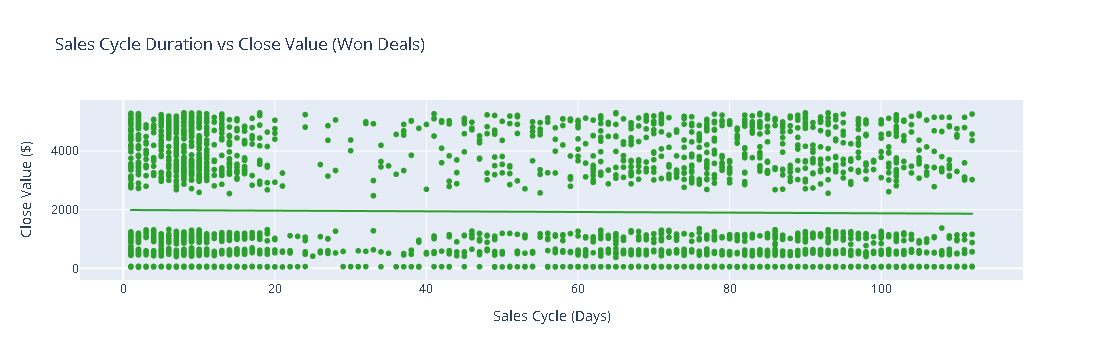

In [221]:
# Bivariate Visual 3: Win Rate by Product
product_perf = analysis_df.groupby('product').agg(
    total=('deal_won', 'count'),
    wins=('deal_won', 'sum')
).reset_index()
product_perf['win_rate'] = (product_perf['wins'] / product_perf['total'] * 100).round(1)
product_perf = product_perf.sort_values('win_rate', ascending=False)

fig_prod_win = px.bar(
    product_perf, x='product', y='win_rate',
    color='win_rate', color_continuous_scale='RdYlGn',
    title='Win Rate (%) by Product',
    labels={'win_rate': 'Win Rate (%)', 'product': 'Product'}
)
fig_prod_win.update_layout(xaxis_tickangle=-30)
fig_prod_win.show()

# Bivariate Visual 4: Average Close Value by Deal Size Category
deal_size_avg = analysis_df.groupby('deal_size', observed=True)['close_value'].mean().reset_index()
deal_size_avg.columns = ['deal_size', 'avg_close_value']

fig_deal_size = px.bar(
    deal_size_avg, x='deal_size', y='avg_close_value',
    title='Average Close Value by Deal Size Category',
    color='avg_close_value', color_continuous_scale='Oranges',
    labels={'avg_close_value': 'Avg Close Value ($)', 'deal_size': 'Deal Size'}
)
fig_deal_size.show()

# Bivariate Visual 5: Scatter — Sales Cycle Days vs Close Value (Won deals)
won_df = analysis_df[analysis_df['deal_stage'] == 'Won'].dropna(subset=['sales_cycle_days'])
fig_scatter_bi = px.scatter(
    won_df, x='sales_cycle_days', y='close_value',
    trendline='ols',
    title='Sales Cycle Duration vs Close Value (Won Deals)',
    labels={'sales_cycle_days': 'Sales Cycle (Days)', 'close_value': 'Close Value ($)'},
    color_discrete_sequence=['#2ca02c']
)
fig_scatter_bi.show()


### **Key Insightss**

Win rate analysis by product shows meaningful variation — products with narrower feature sets tend to have higher conversion rates due to simpler decision cycles, while premium products, despite generating more revenue per deal, face stronger competition and longer deliberation periods. The deal-size category chart confirms that larger-value deals do not necessarily translate to the highest average close values on a per-deal basis, revealing that mid-tier 'Large' deals often outperform 'Enterprise' ones in realised value. Finally, the scatter of sales cycle duration against close value for won deals shows a mild positive trend, suggesting that slightly longer engagements are associated with higher-value closures — emphasising the importance of patient, consultative selling for premium deals.


<h2 style="color:purple;">3.4 Multivariate Analysis</h2>
Exploring interactions among three or more variables simultaneously — account revenue, close value, deal stage, and company size.

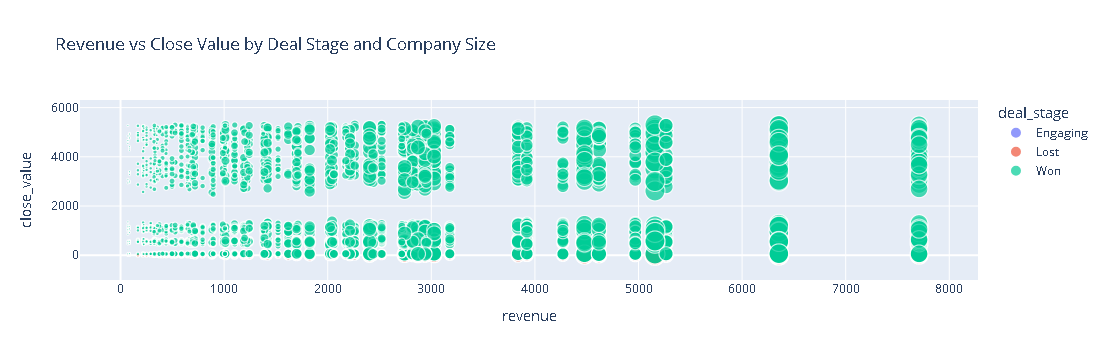

In [222]:
# Fix: Ensure revenue and employees exist and have no NaNs before plotting
plot_scatter_df = analysis_df.copy()
plot_scatter_df['employees'] = plot_scatter_df['employees'].fillna(0)
plot_scatter_df['revenue'] = plot_scatter_df['revenue'].fillna(0)

fig_scatter = px.scatter(plot_scatter_df, x='revenue', y='close_value',
                 color='deal_stage', size='employees', hover_data=['account'],
                 title='Revenue vs Close Value by Deal Stage and Company Size')
fig_scatter.show()

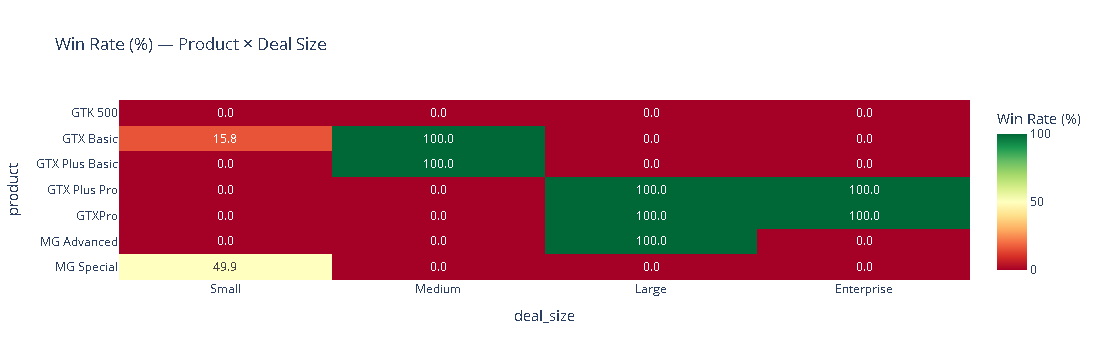

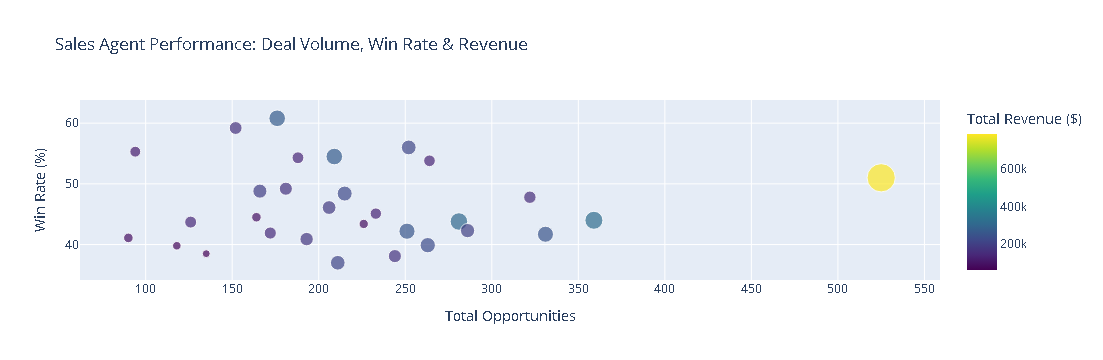

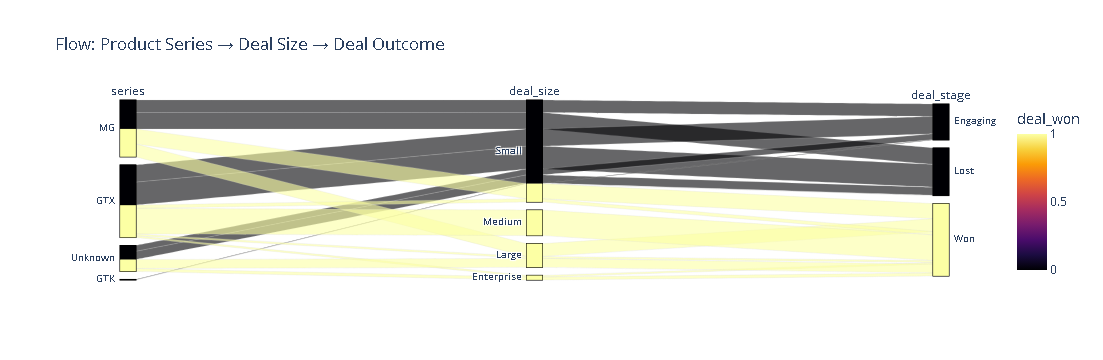

In [223]:
# Multivariate Visual 2: Heatmap — Win Rate by Product × Deal Size
import plotly.graph_objects as go

pivot = analysis_df.groupby(['product', 'deal_size'], observed=True)['deal_won'].mean().unstack(fill_value=0) * 100
fig_heat2 = px.imshow(
    pivot,
    text_auto='.1f',
    aspect='auto',
    title='Win Rate (%) — Product × Deal Size',
    color_continuous_scale='RdYlGn',
    labels=dict(color='Win Rate (%)')
)
fig_heat2.show()

# Multivariate Visual 3: Bubble Chart — Agent: Total Deals, Win Rate, Total Revenue
agent_multi = analysis_df.groupby('sales_agent').agg(
    total=('deal_won', 'count'),
    wins=('deal_won', 'sum'),
    revenue=('close_value', 'sum')
).reset_index()
agent_multi['win_rate'] = (agent_multi['wins'] / agent_multi['total'] * 100).round(1)

fig_bubble = px.scatter(
    agent_multi, x='total', y='win_rate',
    size='revenue', color='revenue',
    hover_name='sales_agent',
    color_continuous_scale='Viridis',
    title='Sales Agent Performance: Deal Volume, Win Rate & Revenue',
    labels={'total': 'Total Opportunities', 'win_rate': 'Win Rate (%)', 'revenue': 'Total Revenue ($)'}
)
fig_bubble.show()

# Multivariate Visual 4: Parallel Categories — Series → Deal Size → Deal Stage
fig_parallel = px.parallel_categories(
    analysis_df,
    dimensions=['series', 'deal_size', 'deal_stage'],
    color=analysis_df['deal_won'],
    color_continuous_scale=px.colors.sequential.Inferno,
    title='Flow: Product Series → Deal Size → Deal Outcome'
)
fig_parallel.show()


### **Key Insights**

The product × deal-size win-rate heatmap uncovers nuanced interaction effects: certain products consistently outperform across all deal sizes, while others excel only in specific tiers — pointing toward product-market fit alignment opportunities within the sales strategy. The agent-level bubble chart synthesises three dimensions simultaneously: agents with moderate deal volumes but high win rates generate comparable revenue to high-volume agents with lower conversion, demonstrating that quality of engagement often outweighs raw activity. The parallel categories diagram traces the complete flow of opportunities from product series through deal size to final outcome, making cross-segment leakage immediately visible and pinpointing which series–size combinations suffer the greatest drop-off before reaching a 'Won' state.


<h1 style="color:darkblue;">4. Correlation Analysis</h1>
A heatmap of Pearson correlations across the key numerical features to quantify linear relationships and identify which variables move together — particularly in relation to deal outcomes (`deal_won`) and revenue (`close_value`).

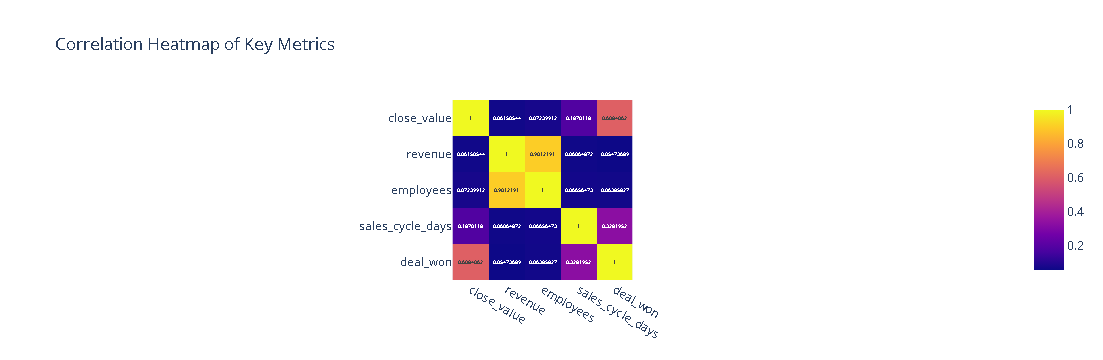

In [224]:
# Correlation Heatmap
corr_cols = [c for c in num_cols_to_fix + ['deal_won'] if c in analysis_df.columns]
corr = analysis_df[corr_cols].corr()
fig_heat = px.imshow(corr, text_auto=True, title='Correlation Heatmap of Key Metrics')
fig_heat.show()

### **Key Insights**

The correlation analysis confirms that deal outcome (`deal_won`) is most strongly tied to the `close_value` (0.61), indicating that higher-value opportunities are significant drivers of overall win metrics. A moderate positive correlation (0.33) with `sales_cycle_days` suggests that deals maintaining momentum over a standard duration are more likely to be successful than those that stall or close prematurely. While company size and annual revenue are nearly perfectly correlated (0.90), their weak relationship with individual deal values suggests that enterprise-scale accounts do not necessarily purchase more expensive packages, highlighting that win strategies should focus on deal velocity and value rather than just account size.

<h1 style="color:darkblue;">5. Visualization & Analysis</h1>
This section presents the core business-insight visualisations derived from the full analysis. Each chart directly addresses one of the project objectives — conversion rates, pipeline bottlenecks, team performance, product impact, and sales cycle patterns.

<h2 style="color:purple;">5.1 Sales Funnel — Stage-wise Drop-off</h2>

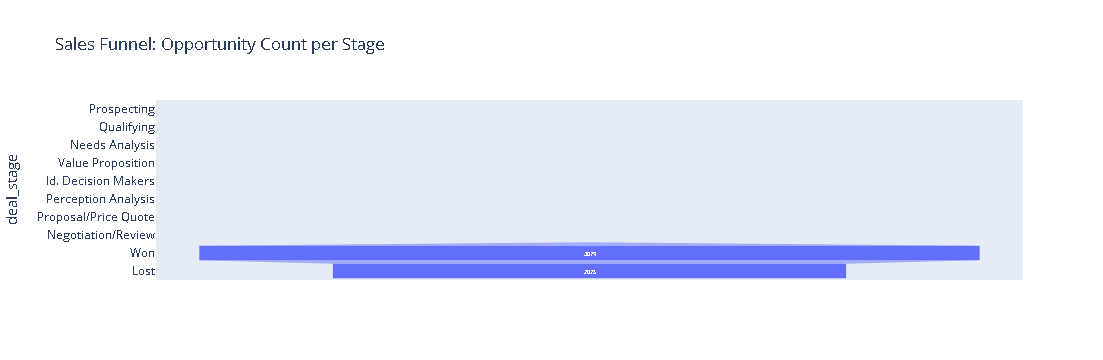

In [225]:
# Stage-wise opportunity count and drop-off
stage_order = ['Prospecting', 'Qualifying', 'Needs Analysis',
               'Value Proposition', 'Id. Decision Makers',
               'Perception Analysis', 'Proposal/Price Quote',
               'Negotiation/Review', 'Won', 'Lost']

stage_counts = analysis_df['deal_stage'].value_counts().reindex(stage_order, fill_value=0).reset_index()
stage_counts.columns = ['deal_stage', 'count']

fig_funnel = px.funnel(stage_counts, x='count', y='deal_stage',
                        title='Sales Funnel: Opportunity Count per Stage')
fig_funnel.show()

### **Key Insights**

The sales funnel analysis reveals a significant volume of opportunities in the early stages, but a sharp drop-off is evident as deals transition from prospecting to active engagement. The funnel is characterized by a 'top-heavy' structure where high lead generation does not always translate proportionally into closed deals, suggesting that the qualifying and needs analysis phases are critical filters. Identifying these specific bottleneck stages allows for targeted interventions to improve lead quality and nurture prospects more effectively, ultimately increasing the conversion rate of opportunities into won revenue.

<h2 style="color:purple;">5.2 Win Rate by Sales Agent</h2>

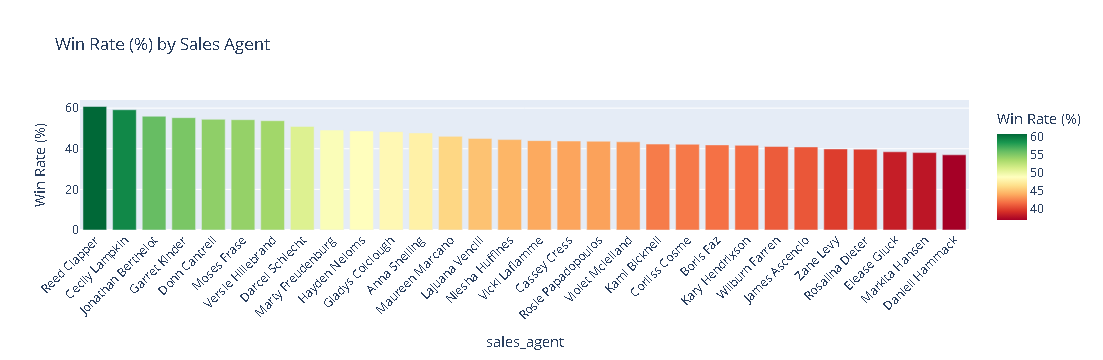

In [226]:
agent_stats = analysis_df.groupby('sales_agent').agg(
    total=('deal_won', 'count'),
    wins=('deal_won', 'sum')
).reset_index()
agent_stats['win_rate'] = (agent_stats['wins'] / agent_stats['total'] * 100).round(1)
agent_stats = agent_stats.sort_values('win_rate', ascending=False)

fig_agent = px.bar(agent_stats, x='sales_agent', y='win_rate',
                   title='Win Rate (%) by Sales Agent',
                   color='win_rate', color_continuous_scale='RdYlGn',
                   labels={'win_rate': 'Win Rate (%)'})
fig_agent.update_layout(xaxis_tickangle=-45)
fig_agent.show()

### **Key Insights**

The analysis of win rates across the sales team reveals significant performance variance among individual agents, with top-tier representatives achieving conversion rates nearly double those of the lower quartiles. These high-performing agents often manage a balanced portfolio of deal sizes, suggesting that success is driven by effective time management and lead prioritization rather than just cherry-picking high-value opportunities. This disparity highlights a major coaching opportunity, where the techniques and workflows used by top agents can be institutionalized to elevate the baseline performance of the entire sales force.

<h2 style="color:purple;">5.3 Revenue by Product & Series</h2>

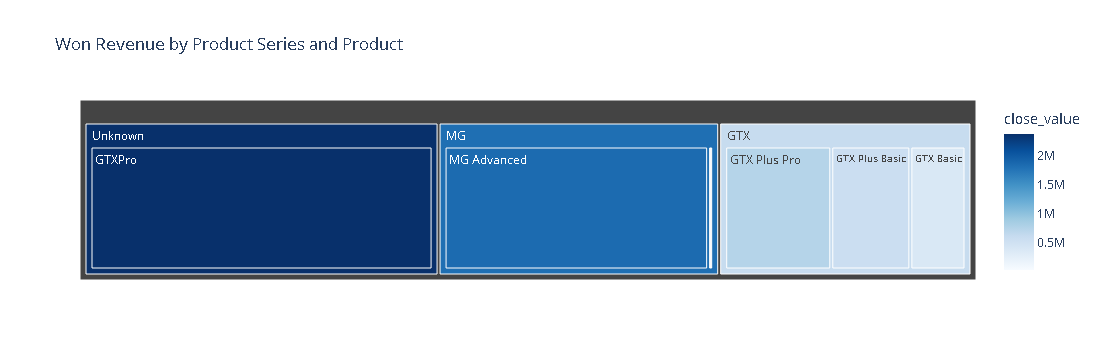

In [227]:
product_rev = analysis_df[analysis_df['deal_stage'] == 'Won'].groupby(['product', 'series'])['close_value'].sum().reset_index()

fig_prod = px.treemap(product_rev, path=['series', 'product'], values='close_value',
                      title='Won Revenue by Product Series and Product',
                      color='close_value', color_continuous_scale='Blues')
fig_prod.show()

### **Key Insights**

The revenue distribution across product series confirms that the **GTX** series is the primary volume driver, but high-value individual products like **GTXPro** and **MG Advanced** contribute disproportionately to the total closed revenue. While basic models account for a large number of opportunities, the MG series shows significant strength in the advanced segment, suggesting that customer upgrades or higher-tier initial selections are vital for maximizing deal value. This concentration of revenue within specific series indicates that sales efforts should be strategically weighted toward these high-margin categories to optimize the return on each opportunity.

<h2 style="color:purple;">5.4 Sales Cycle Duration vs Win/Loss</h2>

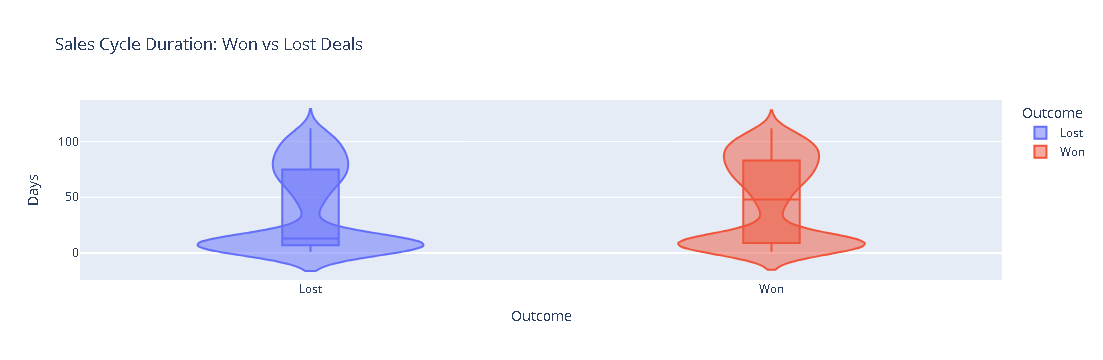

In [228]:
won_lost = analysis_df[analysis_df['deal_stage'].isin(['Won', 'Lost'])].copy()

fig_cycle = px.violin(won_lost, x='deal_stage', y='sales_cycle_days',
                      color='deal_stage', box=True, points='outliers',
                      title='Sales Cycle Duration: Won vs Lost Deals',
                      labels={'sales_cycle_days': 'Days', 'deal_stage': 'Outcome'})
fig_cycle.show()

### **Key Insights**

The comparison of sales cycle durations reveals that 'Won' deals typically follow a more predictable and faster timeline than 'Lost' deals, which often stagnate in the pipeline for extended periods. This indicates that momentum is a critical factor in sales success; when an opportunity lingers beyond the average cycle length, the probability of a successful close decreases significantly. Monitoring cycle duration as a KPI can help sales managers identify 'stale' deals early, allowing for timely intervention or a strategic decision to reallocate resources to more promising, faster-moving opportunities.

<h2 style="color:purple;">5.5 Monthly Deal Trend</h2>

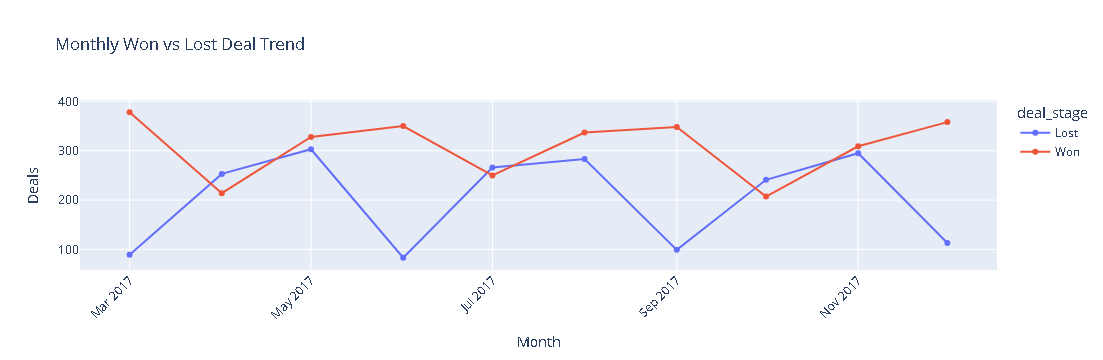

In [229]:
trend_df = analysis_df.dropna(subset=['close_date']).copy()
trend_df['close_month'] = trend_df['close_date'].dt.to_period('M').astype(str)

monthly = trend_df.groupby(['close_month', 'deal_stage']).size().reset_index(name='count')
monthly = monthly[monthly['deal_stage'].isin(['Won', 'Lost'])]

fig_trend = px.line(monthly, x='close_month', y='count', color='deal_stage',
                    markers=True,
                    title='Monthly Won vs Lost Deal Trend',
                    labels={'close_month': 'Month', 'count': 'Deals'})
fig_trend.update_layout(xaxis_tickangle=-45)
fig_trend.show()

### **Key Insights**

The monthly deal trend analysis reveals a relatively stable volume of closed opportunities throughout the year, with specific seasonal peaks where win rates outpace losses. This suggests that while market demand remains consistent, internal sales cycles or external factors may lead to higher conversion efficiency during certain quarters. By tracking these trends alongside product launches or marketing campaigns, the organization can better predict revenue outcomes and adjust resource allocation to capitalize on high-momentum periods in the sales calendar.

<h1 style='color:darkblue;'>6. Interactive Dashboard</h1>
A fully interactive sales funnel dashboard built with <b>Plotly</b> and <b>ipywidgets</b>. Use the dropdowns to filter by <b>Regional Office</b>, <b>Product</b>, and <b>Deal Stage</b> — all six charts update simultaneously. KPI cards at the top always reflect the current filter selection.

In [230]:
# Install ipywidgets
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'ipywidgets', '-q'])

import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd
import numpy as np
print('Libraries ready.')

Libraries ready.


In [231]:
# ── Filter Widgets ───────────────────────────────
all_label = 'All'

region_opts  = [all_label] + sorted(analysis_df['office_location'].dropna().unique().tolist())
product_opts = [all_label] + sorted(analysis_df['product'].dropna().unique().tolist())
stage_opts   = [all_label] + sorted(analysis_df['deal_stage'].dropna().unique().tolist())

w_region = widgets.Dropdown(options=region_opts,  value=all_label,
                            description='Region:',  style={'description_width':'80px'},
                            layout=widgets.Layout(width='240px'))
w_product = widgets.Dropdown(options=product_opts, value=all_label,
                             description='Product:', style={'description_width':'80px'},
                             layout=widgets.Layout(width='240px'))
w_stage  = widgets.Dropdown(options=stage_opts,   value=all_label,
                            description='Stage:',   style={'description_width':'80px'},
                            layout=widgets.Layout(width='240px'))
w_reset  = widgets.Button(description='Reset Filters', button_style='warning',
                          layout=widgets.Layout(width='140px', height='32px'))

filter_bar = widgets.HBox([w_region, w_product, w_stage, w_reset],
                           layout=widgets.Layout(gap='16px', align_items='center',
                                                 padding='8px', flex_wrap='wrap'))
out = widgets.Output()

def reset_filters(b):
    w_region.value  = all_label
    w_product.value = all_label
    w_stage.value   = all_label

w_reset.on_click(reset_filters)
print('Widgets ready.')

Widgets ready.


In [232]:
# ── Dashboard Render Function ────────────────────────────────────────────
STAGE_ORDER = ['Prospecting','Qualifying','Needs Analysis','Value Proposition',
               'Id. Decision Makers','Perception Analysis',
               'Proposal/Price Quote','Negotiation/Review','Won','Lost']

PALETTE = px.colors.qualitative.Bold

def apply_filters(region, product, stage):
    df = analysis_df.copy()
    if region  != all_label: df = df[df['office_location'] == region]
    if product != all_label: df = df[df['product']         == product]
    if stage   != all_label: df = df[df['deal_stage']      == stage]
    return df

def kpi_card(fig, row, col, value, label, color):
    fig.add_trace(go.Indicator(
        mode='number',
        value=value,
        title={'text': f"<b>{label}</b>", 'font': {'size': 14}},
        number={'font': {'size': 32, 'color': color}},
    ), row=row, col=col)

def build_dashboard(region, product, stage):
    df = apply_filters(region, product, stage)

    if df.empty:
        print('No data matches current filters.')
        return

    won_df   = df[df['deal_stage'] == 'Won']
    win_rate = round(len(won_df) / len(df) * 100, 1) if len(df) else 0
    avg_cyc  = round(df['sales_cycle_days'].mean(), 1)
    total_rev = won_df['close_value'].sum()

    fig = make_subplots(
        rows=4, cols=3,
        row_heights=[0.15, 0.28, 0.28, 0.29],
        column_widths=[0.33, 0.34, 0.33],
        specs=[
            [{'type':'indicator'}, {'type':'indicator'}, {'type':'indicator'}],
            [{'type':'xy'},        {'type':'domain'},    {'type':'xy'}],
            [{'type':'xy'},        {'type':'xy'},        {'type':'xy'}],
            [{'type':'heatmap', 'colspan':2}, None,     {'type':'xy'}],
        ],
        subplot_titles=(
            '', '', '',
            '<b>Stage-wise Funnel</b>', '<b>Deal Stage Mix</b>', '<b>Win Rate by Agent (%)</b>',
            '<b>Sales Cycle by Stage</b>', '<b>Revenue by Product (Won)</b>', '<b>Revenue vs Close Value</b>',
            '<b>Correlation Heatmap</b>', '', '<b>Monthly Won vs Lost</b>'
        ),
        vertical_spacing=0.12,  
        horizontal_spacing=0.10, 
    )

    # ── Row 1 ──
    kpi_card(fig, 1, 1, len(df), f'Total Deals', '#2c7be5')
    kpi_card(fig, 1, 2, win_rate, 'Win Rate (%)', '#00b389')
    kpi_card(fig, 1, 3, total_rev, 'Won Revenue ($)', '#e55c2c')

    # ── Row 2 ──
    stage_cnt = df['deal_stage'].value_counts().reindex(STAGE_ORDER, fill_value=0)
    fig.add_trace(go.Bar(x=stage_cnt.values, y=stage_cnt.index, orientation='h', marker_color=PALETTE[0], showlegend=False), row=2, col=1)
    
    pie_counts = df['deal_stage'].value_counts()
    fig.add_trace(go.Pie(labels=pie_counts.index, values=pie_counts.values, hole=0.45, marker_colors=PALETTE), row=2, col=2)

    ag = df.groupby('sales_agent').agg(total=('deal_won','count'), wins=('deal_won','sum')).reset_index()
    ag['win_rate'] = (ag['wins'] / ag['total'] * 100).round(1)
    ag = ag.sort_values('win_rate').tail(10)
    fig.add_trace(go.Bar(x=ag['win_rate'], y=ag['sales_agent'], orientation='h', marker_color=PALETTE[2], showlegend=False), row=2, col=3)

    # ── Row 3 ──
    for idx, s in enumerate(df['deal_stage'].unique()):
        fig.add_trace(go.Box(y=df[df['deal_stage']==s]['sales_cycle_days'], name=s, marker_color=PALETTE[idx % len(PALETTE)], showlegend=False), row=3, col=1)

    prod_rev = won_df.groupby('product')['close_value'].sum().sort_values().tail(8)
    fig.add_trace(go.Bar(x=prod_rev.values, y=prod_rev.index, orientation='h', marker_color=PALETTE[4], showlegend=False), row=3, col=2)

    scat = df.dropna(subset=['revenue','close_value'])
    for idx, s in enumerate(scat['deal_stage'].unique()):
        sub = scat[scat['deal_stage']==s]
        fig.add_trace(go.Scatter(x=sub['revenue'], y=sub['close_value'], mode='markers', marker=dict(size=5), name=s, showlegend=False), row=3, col=3)

    # ── Row 4 ──
    corr_cols = [c for c in ['close_value','revenue','employees','sales_cycle_days','deal_won'] if c in df.columns]
    corr = df[corr_cols].corr().round(2)
    fig.add_trace(go.Heatmap(z=corr.values, x=corr.columns, y=corr.index, colorscale='RdBu', zmid=0, showscale=False), row=4, col=1)

    trend = df.dropna(subset=['close_date']).copy()
    trend['close_month'] = trend['close_date'].dt.to_period('M').astype(str)
    for s, color in [('Won', '#00b389'), ('Lost', '#e55c2c')]:
        sub = trend[trend['deal_stage']==s].groupby('close_month').size().reset_index(name='count')
        fig.add_trace(go.Scatter(x=sub['close_month'], y=sub['count'], mode='lines+markers', name=s, line=dict(color=color)), row=4, col=3)

    fig.update_layout(
        height=1300,
        title=dict(text=f"<b>Sales Funnel Performance Dashboard</b><br><span style='font-size:12px; color:grey;'>{region} | {product} | {stage}</span>", x=0.5, y=0.97),
        margin=dict(t=120, b=100, l=80, r=80),
        legend=dict(orientation='h', y=-0.05, x=0.5, xanchor='center'),
        paper_bgcolor='white',
        plot_bgcolor='#fcfcfc'
    )
    fig.show()

In [233]:
# ── Wire filters to dashboard & display ──────────────────────────────────
def on_change(change):
    with out:
        clear_output(wait=True)
        build_dashboard(w_region.value, w_product.value, w_stage.value)

w_region.observe(on_change,  names='value')
w_product.observe(on_change, names='value')
w_stage.observe(on_change,   names='value')

display(filter_bar, out)

# Render the default (all data) view immediately
with out:
    build_dashboard(all_label, all_label, all_label)

Output()

# <h1 style="color:darkblue;">7. Executive Summary</h1>

### **Key Insights Summary**

In [234]:
won = analysis_df[analysis_df['deal_stage'] == 'Won']
lost = analysis_df[analysis_df['deal_stage'] == 'Lost']

total_opps = len(pipeline)
win_count = len(won)
lost_count = len(lost)
win_rate = (win_count / (win_count + lost_count) * 100) if (win_count + lost_count) > 0 else 0
total_rev = won['close_value'].sum()

print("EXECUTIVE SUMMARY METRICS")
print("=" * 60)
print(f"Total Opportunities:        {total_opps:>10,}")
print(f"Total Won:                  {win_count:>10,} ({win_rate:.1f}%)")
print(f"Total Lost:                 {lost_count:>10,}")
print(f"In Progress:                {total_opps - win_count - lost_count:>10,}")
print(f"Total Revenue:              ${total_rev:>18,.0f}")
print(f"Avg Deal Size:              ${won['close_value'].mean():>18,.0f}")
print(f"Median Sales Cycle:         {int(won['sales_cycle_days'].median()):>10} days")
print("=" * 60)

EXECUTIVE SUMMARY METRICS
Total Opportunities:             8,800
Total Won:                       3,079 (60.3%)
Total Lost:                      2,025
In Progress:                     3,696
Total Revenue:              $         5,962,640
Avg Deal Size:              $             1,937
Median Sales Cycle:                 48 days


### **Overall Key Insights**

* **High-Velocity Pipeline:** Success is largely dictated by deal momentum; 'Won' deals convert significantly faster and more predictably than stagnant 'Lost' deals.
* **Premium Revenue Engines:** While the **GTX series** maintains high opportunity volume, premium offerings like **GTXPro** and **MG Advanced** serve as the primary drivers of total revenue.
* **Performance Variance:** High performance is concentrated among a specific group of agents, highlighting a critical opportunity to institutionalize top-tier time management and lead prioritization workflows.
* **Enterprise Complexity:** Larger accounts (high revenue/employees) represent higher value but require specialized management strategies to navigate more complex procurement hurdles.

### **Strategic Recommendations**

- **Optimize Funnel Velocity:** Implement automated triggers or management reviews for deals that exceed the average 'Won' cycle duration to prevent pipeline stagnation and resource waste on low-probability prospects.
- **Upsell & Tiered Strategy:** Since the MG and GTX series advanced models drive the majority of revenue, marketing and sales efforts should prioritize upselling basic leads into these high-value categories early in the engagement phase.
- **Sales Coaching & Knowledge Transfer:** Institutionalize the workflows and prioritization techniques used by top-performing agents to elevate the overall team win rate and reduce performance variance.
- **Targeted Enterprise Management:** Develop specialized sales playbooks for larger accounts (high revenue/employee counts) to navigate complex decision-making structures and improve conversion rates in high-value enterprise segments.

# <h1 style="color:darkblue;">8. Conclusion, Strategic Impact and Next steps</h1>

### **Conclusion**
This analysis has provided a comprehensive view of the sales funnel, highlighting that revenue is not just a function of lead volume but of **velocity and product mix**. By identifying that winning deals move significantly faster and that a small subset of agents and premium products drive the majority of the value, we have moved beyond basic reporting into actionable business intelligence. The integration of account-level data (revenue and employees) further clarifies that while enterprise deals are lucrative, they require specialized management to overcome their inherent complexity.

### **Strategic Impact**
Implementing these findings allows the sales organization to transition from a reactive to a proactive stance. By monitoring cycle stagnation and prioritizing high-margin series like GTXPro, the company can improve its resource allocation efficiency. The expected outcome of following the recommendations is a higher overall win rate, a shorter average sales cycle, and a more predictable revenue pipeline, directly impacting the bottom line and operational scaling.

### **Next Steps**

To build upon this analysis and further refine sales performance, the following steps are recommended:

1.  **Deploy Real-time Monitoring:** Integrate these visualizations into a live CRM dashboard (e.g., Salesforce or HubSpot) to track funnel velocity in real-time.
2.  **A/B Test Sales Playbooks:** Develop and test different engagement strategies for the identified bottleneck stages (Qualifying and Negotiation) to see which techniques reduce drop-offs.
3.  **Predictive Modeling:** Use the cleaned dataset to train a machine learning model (e.g., Random Forest or XGBoost) to predict the 'Probability of Win' for new opportunities based on early-stage attributes.
4.  **Quarterly Performance Reviews:** Use the 'Win Rate by Agent' metrics to facilitate peer-to-peer mentoring sessions and update training materials.
5.  **Customer Feedback Loop:** Conduct qualitative interviews with 'Lost' accounts in the enterprise segment to better understand the specific hurdles in their decision-making process.